In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
rfm = pd.read_csv("data/rfm_features.csv")


In [3]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [4]:
x = rfm[["Recency","Frequency","Monetary"]]

In [5]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
inertia = []
silhouette_scores = []

k_range = range(2,9)
for i in k_range:
    kmeans = KMeans(n_clusters=i, n_init=10,init="k-means++", random_state= 42)
    labels = kmeans.fit_predict(x_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_scaled,labels))


In [8]:
import matplotlib.pyplot as plt

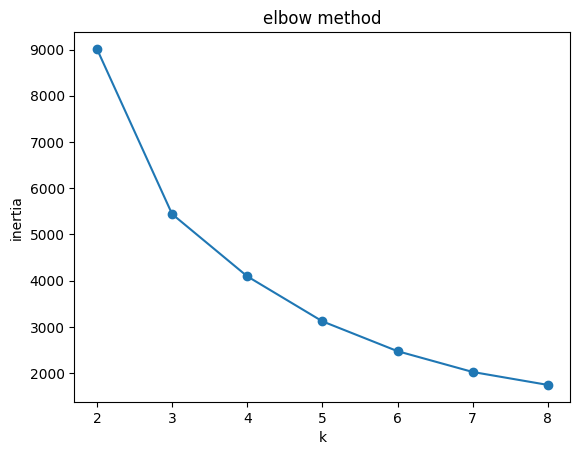

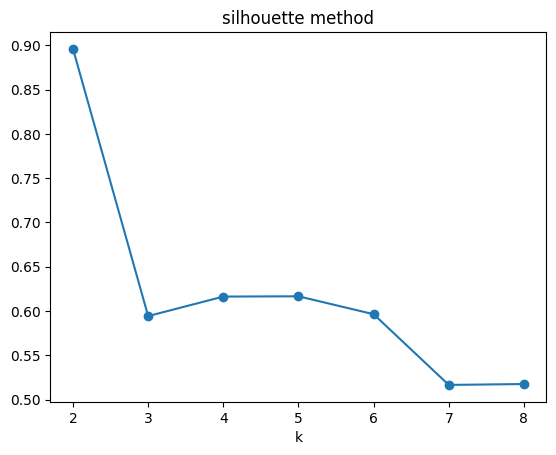

In [9]:
plt.figure()
plt.plot(k_range,inertia, marker = "o")
plt.title("elbow method")
plt.xlabel("k")
plt.ylabel("inertia")

plt.figure()
plt.plot(k_range, silhouette_scores, marker = "o")
plt.xlabel("k")
plt.title("silhouette method")

plt.show()

In [10]:
# so k is 5

In [11]:
k = 4
kmeans_model = KMeans(n_clusters=k,n_init=10, random_state=42)
rfm["Cluster"] = kmeans_model.fit_predict(x_scaled)

In [12]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [13]:
rfm["Cluster"].unique()

array([3, 0, 1, 2], dtype=int32)

# interpreting the clusters

In [14]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency" : "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID":"count"
})

In [15]:
cluster_summary.head(2)

,Recency,Frequency,Monetary,CustomerID
Cluster,,,,
0,43.702685,3.682711,1359.049284,3054
1,248.075914,1.552015,480.617480,1067


In [16]:
cluster_summary = cluster_summary.rename(columns={"CustomerID":"count"})

In [17]:
cluster_summary

,Recency,Frequency,Monetary,count
Cluster,,,,
0,43.702685,3.682711,1359.049284,3054
1,248.075914,1.552015,480.617480,1067
2,7.384615,82.538462,127338.313846,13
3,15.500000,22.333333,12709.090490,204


Now we have got the overall idea about the customers and their segments.  
We are going to tag the clusters. So that personalized attention can be given

<!-- cluster 4 -> vip list, cluster 3 -> Frequent safe customers, cluster 1 -> one time customers, cluster 0 -> at risk customers, 2 - growth potential -->

cluster 2 -> vip list,  
cluster 3 -> loyal customers  
cluster 1 -> one time customers  
cluster 0 -> recent customers, who can can converted to normal customers  


In [18]:
# cluster_summary = cluster_summary.reset_index()
# segment_map = {
#     0: "Risk Customers",
#     1: "One time customers",
#     2: "growth potential",
#     3: "Frequent safe customers",
#     4: "Vip list"
# }

segment_map = {
    0: "Recent customers",
    1: "One time customers",
    2: "Vip list",
    3: "Loyal customers"
}
rfm["Tags"] = rfm["Cluster"].map(segment_map)

In [19]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Tags
0,12346.0,326,1,77183.60,3,Loyal customers
1,12347.0,2,7,4310.00,0,Recent customers
2,12348.0,75,4,1797.24,0,Recent customers
3,12349.0,19,1,1757.55,0,Recent customers
4,12350.0,310,1,334.40,1,One time customers


## visualizing the x_scaled.. for understanding

In [20]:
from sklearn.decomposition import PCA

In [21]:
pca = PCA(n_components=2)

In [22]:
x_pca = pca.fit_transform(x_scaled)

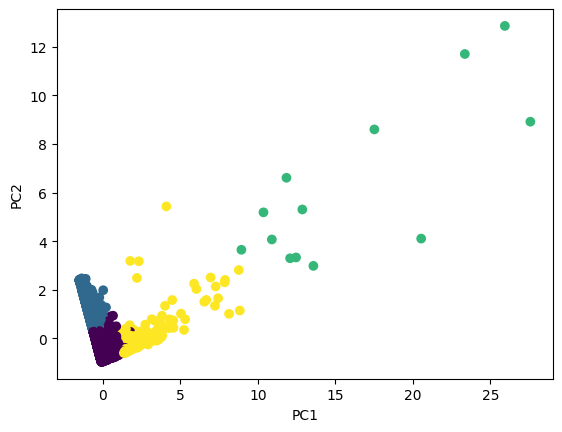

In [23]:
plt.figure()
plt.scatter(x_pca[:,0],x_pca[:,1],c = rfm["Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [24]:
# saving the artifacts

In [25]:
import joblib

In [26]:
joblib.dump(kmeans_model,"models/kmeans_model.joblib")

['models/kmeans_model.joblib']

In [27]:
joblib.dump(scaler,"models/rfm_scaler.joblib")

['models/rfm_scaler.joblib']

In [28]:
rfm["CustomerID"] = rfm["CustomerID"].astype(int)

In [29]:
# joblib.dump("rfm","data/rfm_with_cluster.csv")
rfm.to_csv("data/rfm_with_cluster.csv",index=False)